Output()

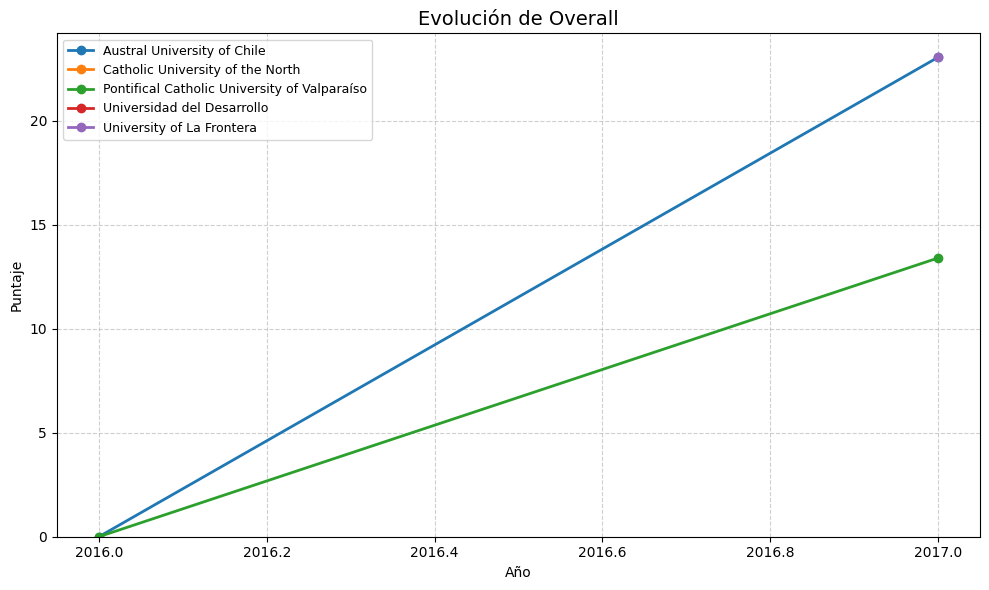

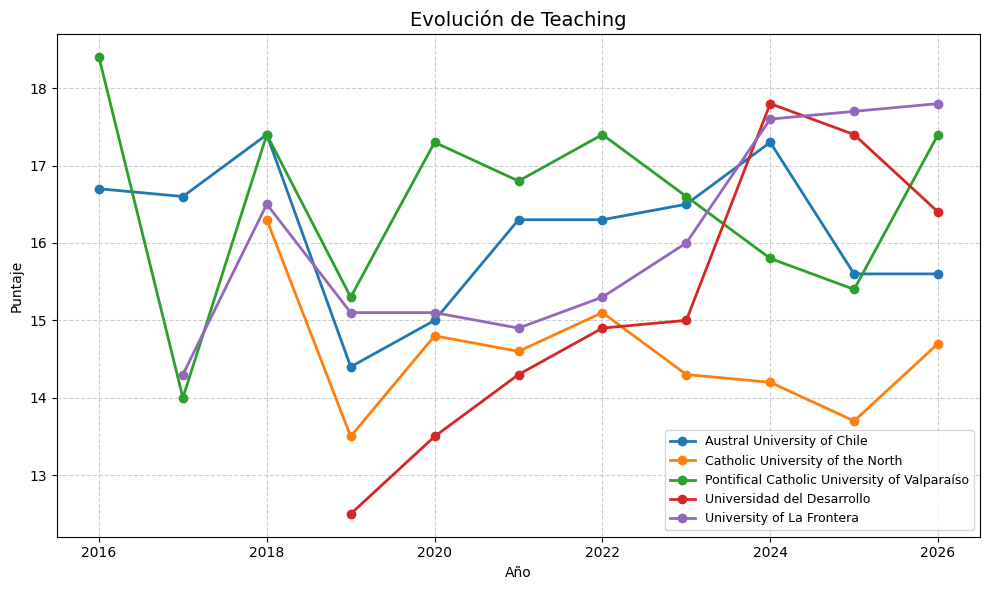

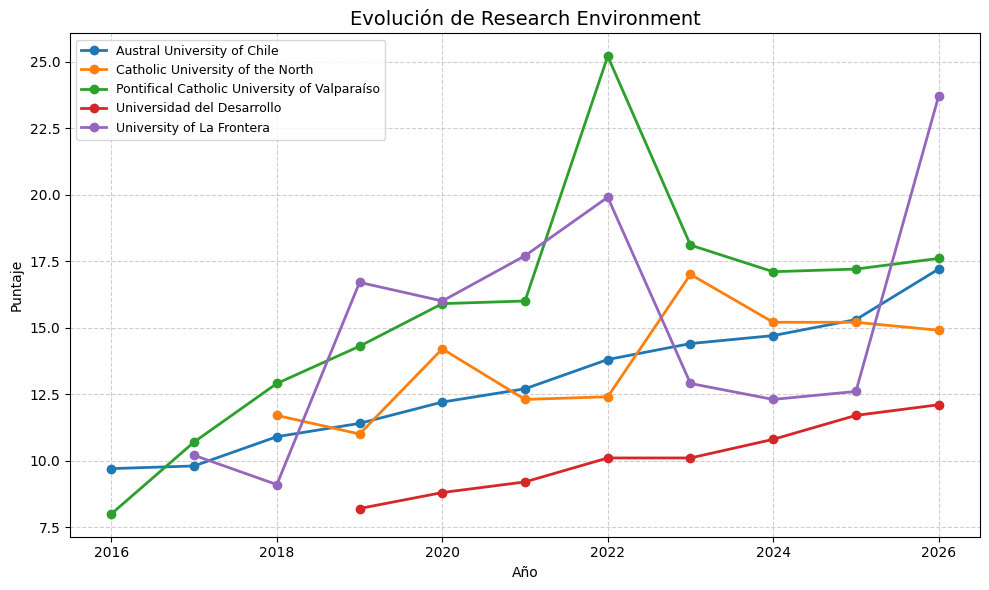

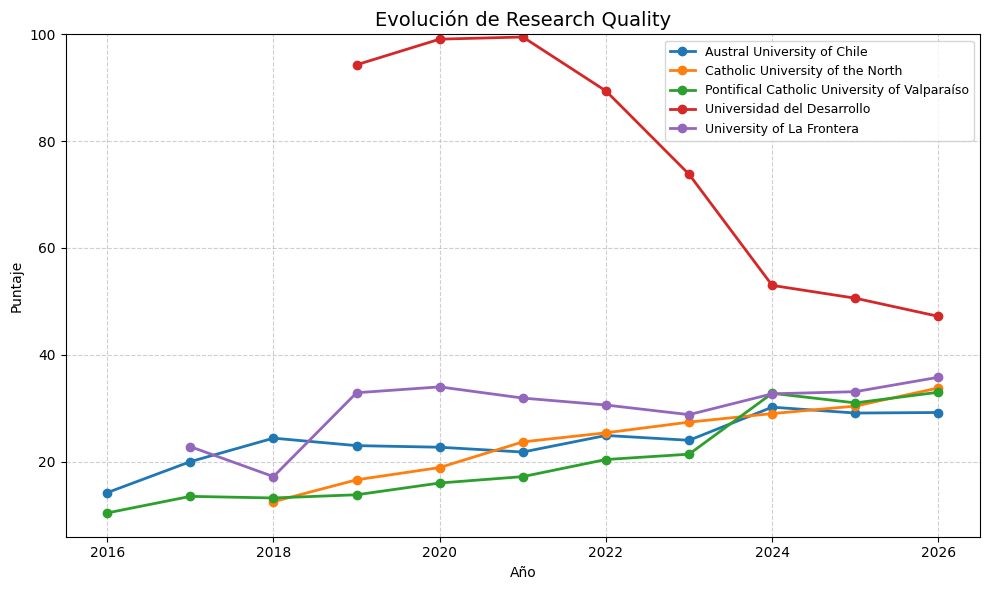

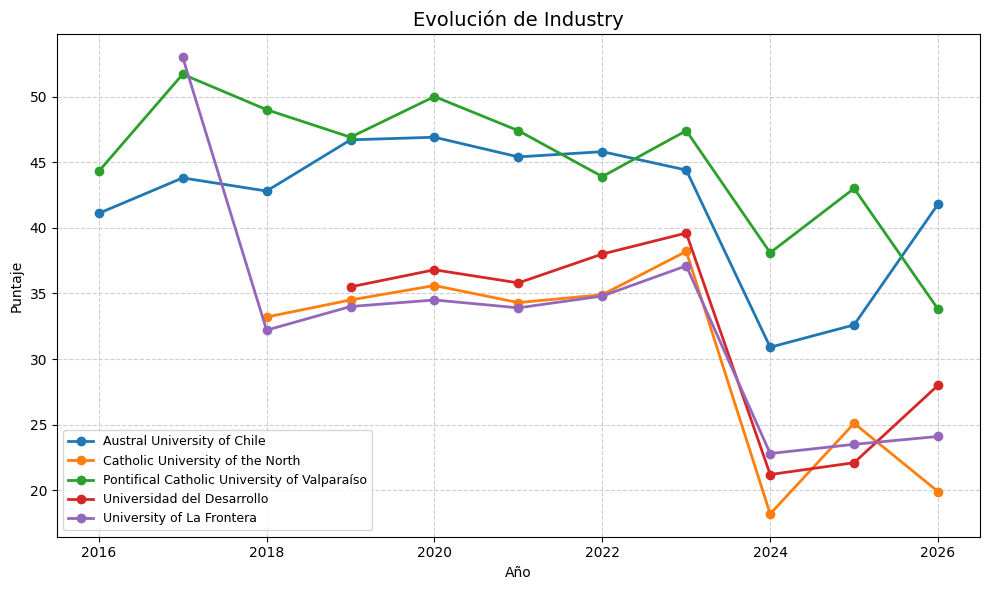

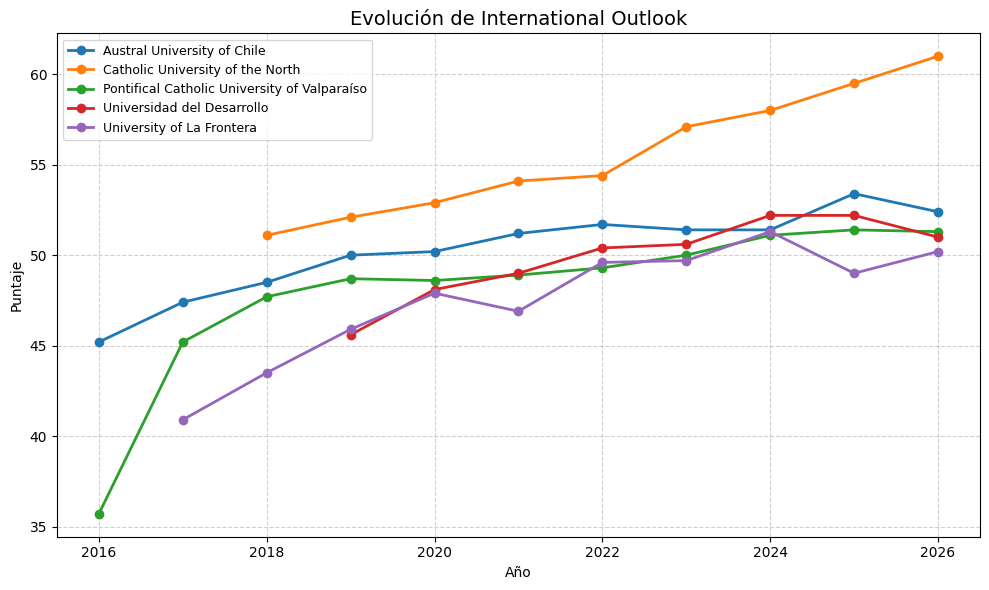

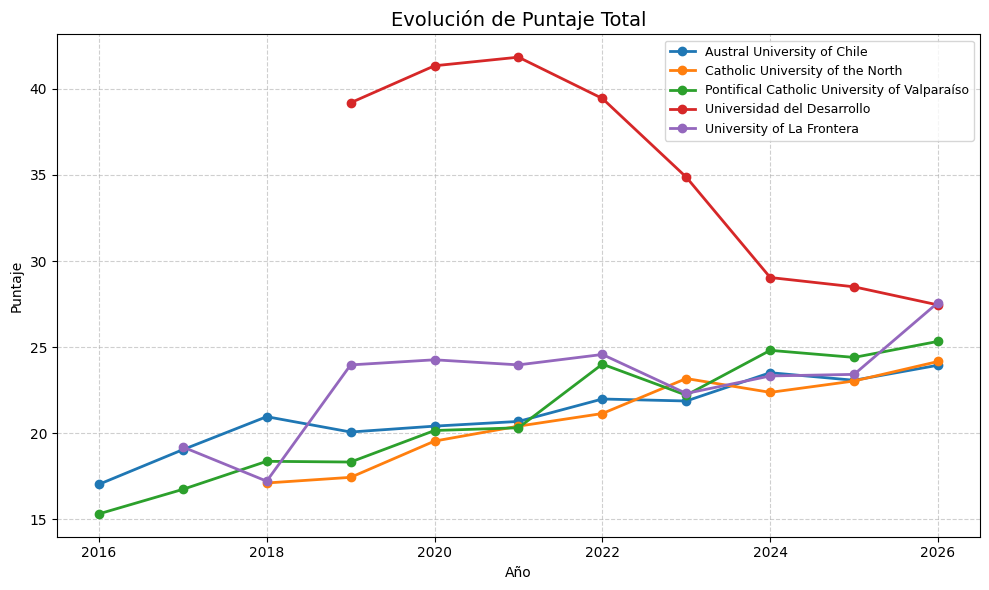

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
from ipywidgets import Checkbox, VBox, Button, Output
from IPython.display import display

# Función parse_value (maneja rangos y numéricos)
def parse_value(val):
    if pd.isna(val) or val == '':
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    val_str = str(val).strip()
    if '—' in val_str or '-' in val_str:
        parts = re.split(r'[—\-]', val_str)
        try:
            low = float(parts[0].strip())
            high = float(parts[1].strip())
            return (low + high) / 2
        except:
            return np.nan
    else:
        try:
            return float(val_str)
        except:
            return np.nan

# Pesos de cada métrica
PESOS = {
    'Teaching': 0.295,
    'Research Environment': 0.29,
    'Research Quality': 0.30,
    'Industry': 0.04,
    'International Outlook': 0.075
}

# Cargar archivos
file_pattern = "THE_*_engineering_rankings.csv"
files = glob.glob(file_pattern)
if not files:
    from google.colab import files
    print("No se encontraron archivos. Suba los CSV:")
    uploaded = files.upload()
    files = list(uploaded.keys())

dfs = []
for file in sorted(files):
    df = pd.read_csv(file)
    if 'year' not in df.columns:
        m = re.search(r'THE_(\d{4})_', file)
        if m:
            df['year'] = int(m.group(1))
        else:
            continue
    metrics = ['Overall', 'Teaching', 'Research Environment', 'Research Quality', 'Industry', 'International Outlook']
    for metric in metrics:
        if metric in df.columns:
            df[metric] = df[metric].apply(parse_value)
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)
full_df = full_df.sort_values(['Name', 'year'])

# Calcular Puntaje Total
def calcular_puntaje_total(row):
    total = 0
    for metric, peso in PESOS.items():
        valor = row.get(metric, np.nan)
        if pd.notna(valor):
            total += valor * peso
    return total if any(pd.notna(row.get(m, np.nan)) for m in PESOS.keys()) else np.nan

full_df['Puntaje Total'] = full_df.apply(calcular_puntaje_total, axis=1)

universidades = sorted(full_df['Name'].unique())

# Casillas de selección
checkboxes = {uni: Checkbox(value=False, description=uni) for uni in universidades}
select_all = Checkbox(value=False, description="Seleccionar todas")

def on_select_all_change(change):
    for cb in checkboxes.values():
        cb.value = change['new']
select_all.observe(on_select_all_change, names='value')

button = Button(description="Graficar seleccionadas")
out = Output()

def plot_selected(b):
    selected = [uni for uni, cb in checkboxes.items() if cb.value]
    if not selected:
        with out:
            print("No se seleccionó ninguna universidad.")
        return
    plot_df = full_df[full_df['Name'].isin(selected)].copy()
    metrics = ['Overall', 'Teaching', 'Research Environment', 'Research Quality', 'Industry', 'International Outlook', 'Puntaje Total']
    with out:
        out.clear_output()
        print(f"Gráficos para: {', '.join(selected)}")
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        # Calcular límites dinámicos (ignorando NaN)
        values = []
        for uni in selected:
            data = plot_df[plot_df['Name'] == uni][metric].dropna()
            values.extend(data)
        if values:
            min_val = min(values)
            max_val = max(values)
            margin = (max_val - min_val) * 0.05
            y_low = max(0, min_val - margin)
            y_high = min(100, max_val + margin)
        else:
            y_low, y_high = 0, 100
        for uni in selected:
            data = plot_df[plot_df['Name'] == uni].sort_values('year')
            plt.plot(data['year'], data[metric], marker='o', linestyle='-', linewidth=2, label=uni)
        plt.title(f'Evolución de {metric}', fontsize=14)
        plt.xlabel('Año')
        plt.ylabel('Puntaje')
        plt.ylim(y_low, y_high)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best', fontsize=9)
        plt.tight_layout()
        plt.show()

button.on_click(plot_selected)

ui = VBox([select_all, VBox(list(checkboxes.values())), button])
display(ui, out)